# GAN — Генеративно-состязательная сеть
Генерация рукописных цифр

## Как работает GAN
```
┌─────────────┐     случайный      ┌─────────────┐     фейковое     ┌───────────────┐
│             │       шум          │             │    изображение   │               │
│   Шум z     │ ──────────────────>│  Generator  │ ────────────────>│ Discriminator │──> Real/Fake?
│  (100 чисел)│                    │  (Художник) │                  │   (Критик)    │
└─────────────┘                    └─────────────┘                  └───────────────┘
                                                                           ↑
                                   ┌─────────────┐     реальное            │
                                   │   MNIST     │    изображение          │
                                   │   Dataset   │ ─────────────────────────
                                   └─────────────┘

• Generator (Генератор) — учится создавать реалистичные изображения из шума
• Discriminator (Дискриминатор) — учится отличать реальные от фейковых
• Они соревнуются друг с другом → оба становятся лучше
```

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from IPython.display import clear_output

print('TensorFlow:', tf.__version__)

C:\Users\Ruslan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


TensorFlow: 2.20.0


## 1. Загрузка данных

In [2]:
# Загружаем MNIST
(x_train, _), (_, _) = keras.datasets.mnist.load_data()

# Нормализация в диапазон [-1, 1] (лучше для GAN)
x_train = x_train.astype('float32')
x_train = (x_train - 127.5) / 127.5
x_train = x_train.reshape(-1, 28, 28, 1)

print('Форма данных:', x_train.shape)
print('Диапазон значений:', x_train.min(), 'to', x_train.max())

Форма данных: (60000, 28, 28, 1)
Диапазон значений: -1.0 to 1.0


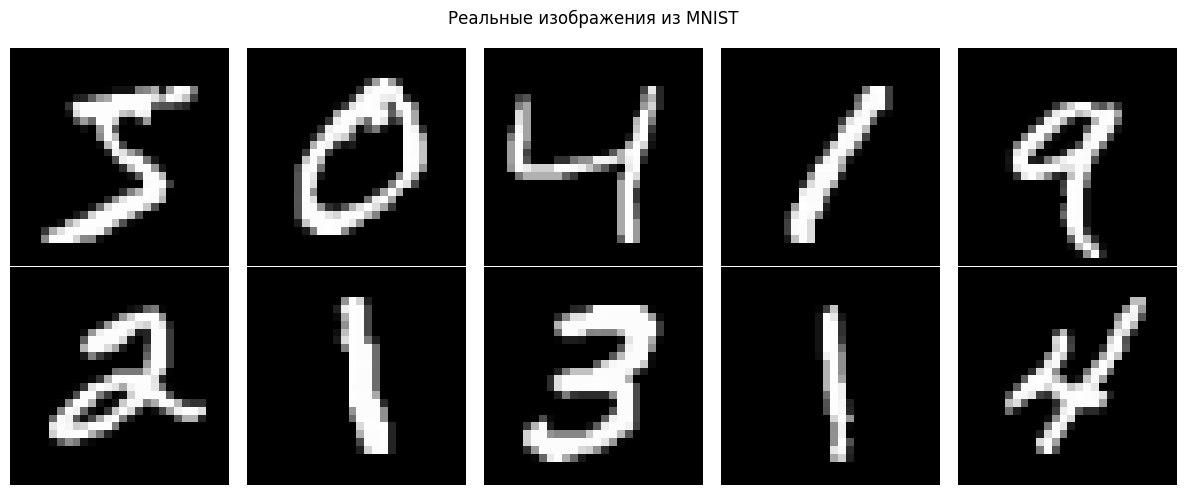

In [3]:
# Примеры реальных изображений
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i].reshape(28, 28), cmap='gray')
    ax.axis('off')
plt.suptitle('Реальные изображения из MNIST')
plt.tight_layout()
plt.show()

## 2. Создание Generator (Генератора)

In [4]:
# Размер случайного вектора (латентное пространство)
LATENT_DIM = 100

def build_generator():
    model = keras.Sequential([
        # Вход: случайный вектор 100 чисел
        layers.Input(shape=(LATENT_DIM,)),
        
        # Полносвязный слой → 7x7x256
        layers.Dense(7 * 7 * 256, use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(0.2),
        layers.Reshape((7, 7, 256)),
        
        # Увеличиваем размер: 7x7 → 14x14
        layers.Conv2DTranspose(128, (5, 5), strides=(1, 1), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(0.2),
        
        # 14x14 → 14x14
        layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(0.2),
        
        # 14x14 → 28x28
        layers.Conv2DTranspose(1, (5, 5), strides=(2, 2), padding='same', use_bias=False, activation='tanh')
    ], name='generator')
    
    return model

generator = build_generator()
generator.summary()

Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12544)          │     1,254,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12544)          │        50,176 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 7, 7, 128)      │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 14, 14, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │         1,600 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,330,944 (8.89 MB)

 Trainable params: 2,305,472 (8.79 MB)

 Non-trainable params: 25,472 (99.50 KB)

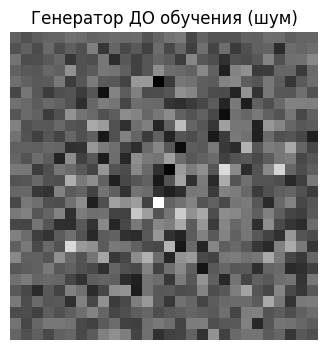

In [5]:
# Тест генератора (до обучения - просто шум)
noise = tf.random.normal([1, LATENT_DIM])
generated_image = generator(noise, training=False)

plt.figure(figsize=(4, 4))
plt.imshow(generated_image[0, :, :, 0], cmap='gray')
plt.title('Генератор ДО обучения (шум)')
plt.axis('off')
plt.show()

## 3. Создание Discriminator (Дискриминатора)

In [6]:
def build_discriminator():
    model = keras.Sequential([
        # Вход: изображение 28x28x1
        layers.Input(shape=(28, 28, 1)),
        
        # Свёртки для извлечения признаков
        layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same'),
        layers.LeakyReLU(0.2),
        layers.Dropout(0.3),
        
        layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'),
        layers.LeakyReLU(0.2),
        layers.Dropout(0.3),
        
        # Классификация: Real (1) или Fake (0)
        layers.Flatten(),
        layers.Dense(1)  # без активации для binary crossentropy from logits
    ], name='discriminator')
    
    return model

discriminator = build_discriminator()
discriminator.summary()

Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,865 (831.50 KB)

 Trainable params: 212,865 (831.50 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Функции потерь и оптимизаторы

In [7]:
# Binary Cross Entropy
cross_entropy = keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(real_output, fake_output):
    """Дискриминатор хочет: real→1, fake→0"""
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

def generator_loss(fake_output):
    """Генератор хочет обмануть дискриминатор: fake→1"""
    return cross_entropy(tf.ones_like(fake_output), fake_output)

# Оптимизаторы
generator_optimizer = keras.optimizers.Adam(1e-4)
discriminator_optimizer = keras.optimizers.Adam(1e-4)

print('Функции потерь и оптимизаторы готовы')

Функции потерь и оптимизаторы готовы


## 5. Шаг обучения

In [8]:
BATCH_SIZE = 256

@tf.function
def train_step(images):
    # Генерируем случайный шум
    noise = tf.random.normal([BATCH_SIZE, LATENT_DIM])
    
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        # Генератор создаёт фейковые изображения
        generated_images = generator(noise, training=True)
        
        # Дискриминатор оценивает реальные и фейковые
        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)
        
        # Считаем потери
        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)
    
    # Обновляем веса
    gen_gradients = gen_tape.gradient(gen_loss, generator.trainable_variables)
    disc_gradients = disc_tape.gradient(disc_loss, discriminator.trainable_variables)
    
    generator_optimizer.apply_gradients(zip(gen_gradients, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(disc_gradients, discriminator.trainable_variables))
    
    return gen_loss, disc_loss

print('Функция обучения готова')

Функция обучения готова


## 6. Визуализация прогресса

In [9]:
# Фиксированный шум для отслеживания прогресса
SEED = tf.random.normal([16, LATENT_DIM])

def generate_and_show_images(epoch):
    """Генерирует и показывает изображения"""
    predictions = generator(SEED, training=False)
    
    fig, axes = plt.subplots(4, 4, figsize=(8, 8))
    for i, ax in enumerate(axes.flat):
        ax.imshow(predictions[i, :, :, 0] * 127.5 + 127.5, cmap='gray')
        ax.axis('off')
    plt.suptitle(f'Эпоха {epoch}')
    plt.tight_layout()
    plt.show()

print('Функция визуализации готова')

Функция визуализации готова


## 7. Обучение GAN

In [10]:
# Параметры обучения
EPOCHS = 30  # Увеличь до 50-100 для лучших результатов
BATCH_SIZE = 256

# Создаём датасет
dataset = tf.data.Dataset.from_tensor_slices(x_train)
dataset = dataset.shuffle(60000).batch(BATCH_SIZE)

# История потерь
g_losses = []
d_losses = []

print(f'Начинаем обучение на {EPOCHS} эпох...')
print(f'Батчей в эпохе: {len(x_train) // BATCH_SIZE}')
print('='*50)

Начинаем обучение на 30 эпох...
Батчей в эпохе: 234


In [12]:
import time

for epoch in range(1, EPOCHS + 1):
    start = time.time()
    
    epoch_g_loss = []
    epoch_d_loss = []
    
    for image_batch in dataset:
        if len(image_batch) == BATCH_SIZE:  # Пропускаем неполные батчи
            g_loss, d_loss = train_step(image_batch)
            epoch_g_loss.append(g_loss)
            epoch_d_loss.append(d_loss)
    
    # Средние потери за эпоху
    g_losses.append(np.mean(epoch_g_loss))
    d_losses.append(np.mean(epoch_d_loss))
    
    # Выводим прогресс каждые 5 эпох
    if epoch % 5 == 0 or epoch == 1:
        clear_output(wait=True)
        print(f'Эпоха {epoch}/{EPOCHS}')
        print(f'  G Loss: {g_losses[-1]:.4f}')
        print(f'  D Loss: {d_losses[-1]:.4f}')
        print(f'  Время: {time.time()-start:.1f}s')
        generate_and_show_images(epoch)

print('\nОбучение завершено!')

KeyboardInterrupt: 

## 8. Графики обучения

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(g_losses, label='Generator Loss')
plt.plot(d_losses, label='Discriminator Loss')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.title('Потери во время обучения')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
# Генерируем финальные изображения
final_images = generator(SEED, training=False)
for i in range(4):
    plt.subplot(2, 4, 5+i)
    plt.imshow(final_images[i, :, :, 0] * 127.5 + 127.5, cmap='gray')
    plt.axis('off')

plt.suptitle('Результаты обучения GAN')
plt.tight_layout()
plt.show()

## 9. Генерация новых изображений

In [ ]:
# Генерируем 25 новых цифр
new_noise = tf.random.normal([25, LATENT_DIM])
new_images = generator(new_noise, training=False)

fig, axes = plt.subplots(5, 5, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(new_images[i, :, :, 0] * 127.5 + 127.5, cmap='gray')
    ax.axis('off')
plt.suptitle('Сгенерированные цифры (полностью новые!)', fontsize=14)
plt.tight_layout()
plt.show()

print('Эти цифры не существовали в датасете — они созданы генератором!')

## 10. Интерполяция в латентном пространстве

In [ ]:
# Плавный переход между двумя случайными точками
z1 = tf.random.normal([1, LATENT_DIM])
z2 = tf.random.normal([1, LATENT_DIM])

# Интерполяция
steps = 10
interpolated = []
for alpha in np.linspace(0, 1, steps):
    z = z1 * (1 - alpha) + z2 * alpha
    img = generator(z, training=False)
    interpolated.append(img[0, :, :, 0])

fig, axes = plt.subplots(1, steps, figsize=(20, 3))
for i, ax in enumerate(axes):
    ax.imshow(interpolated[i] * 127.5 + 127.5, cmap='gray')
    ax.axis('off')
plt.suptitle('Интерполяция: плавный переход между двумя цифрами')
plt.tight_layout()
plt.show()

print('Латентное пространство непрерывно — можно плавно переходить между изображениями')

## Итог

```
┌─────────────────────────────────────────────────────────────┐
│                         GAN                                 │
├─────────────────────────────────────────────────────────────┤
│  Generator      — создаёт изображения из шума               │
│  Discriminator  — отличает реальные от фейковых             │
│  Обучение       — состязание (adversarial training)         │
├─────────────────────────────────────────────────────────────┤
│  Применения:                                                │
│  • Генерация лиц (StyleGAN)                                 │
│  • Улучшение разрешения (Super Resolution)                  │
│  • Перенос стиля (CycleGAN)                                 │
│  • Генерация изображений по тексту (предшественник DALL-E)  │
└─────────────────────────────────────────────────────────────┘
```